# Iris Flower Classification
## CodeAlpha Data Science Internship — Task 1
**Author:** Muhammad Abdul Rehman  
**Dataset:** Iris Flower Dataset (Kaggle)  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Overview

In [14]:
df = pd.read_csv("Iris.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())
print("\nSpecies Distribution:")
print(df['Species'].value_counts())

Shape: (150, 6)

First 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(

## 2. Data Cleaning

In [15]:
print("Missing Values:")
print(df.isnull().sum())

# Drop Id column, not needed for ML
df.drop('Id', axis=1, inplace=True)
print("\nId column dropped!")
print("New shape:", df.shape)

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Id column dropped!
New shape: (150, 5)


## 3. Data Visualization

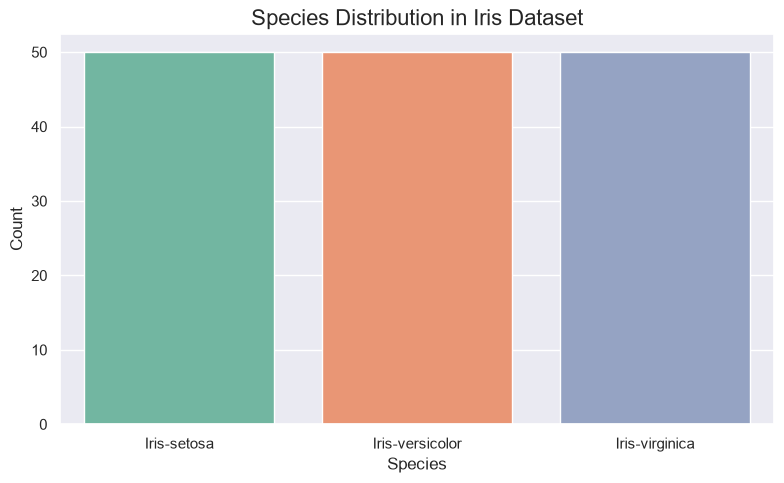

In [16]:
# species distribution plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Species', hue='Species', palette='Set2', legend=False)
plt.title("Species Distribution in Iris Dataset", fontsize=16)
plt.xlabel("Species")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

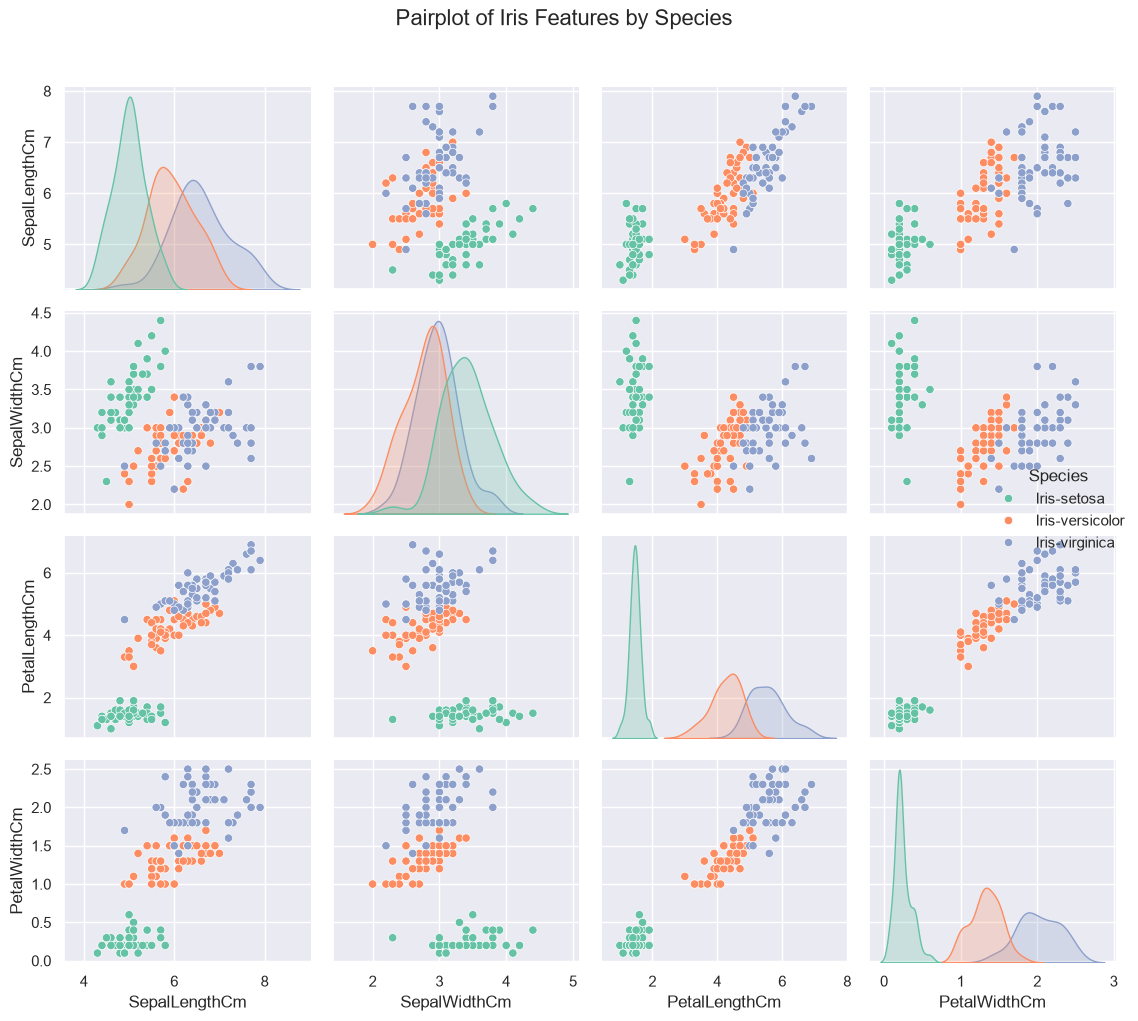

In [17]:
# pairplot of features colored by species
sns.pairplot(df, hue='Species', palette='Set2')
plt.suptitle("Pairplot of Iris Features by Species", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

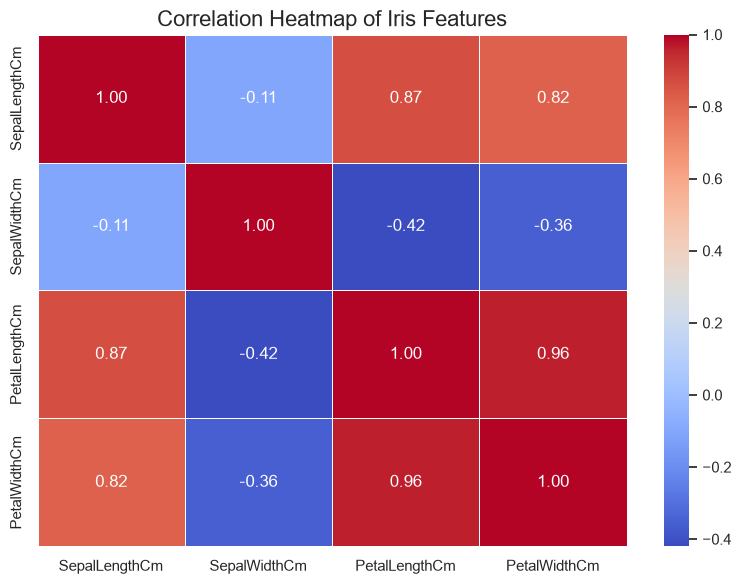

In [18]:
# correlation heatmap of features
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('Species', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Iris Features", fontsize=16)
plt.tight_layout()
plt.show()

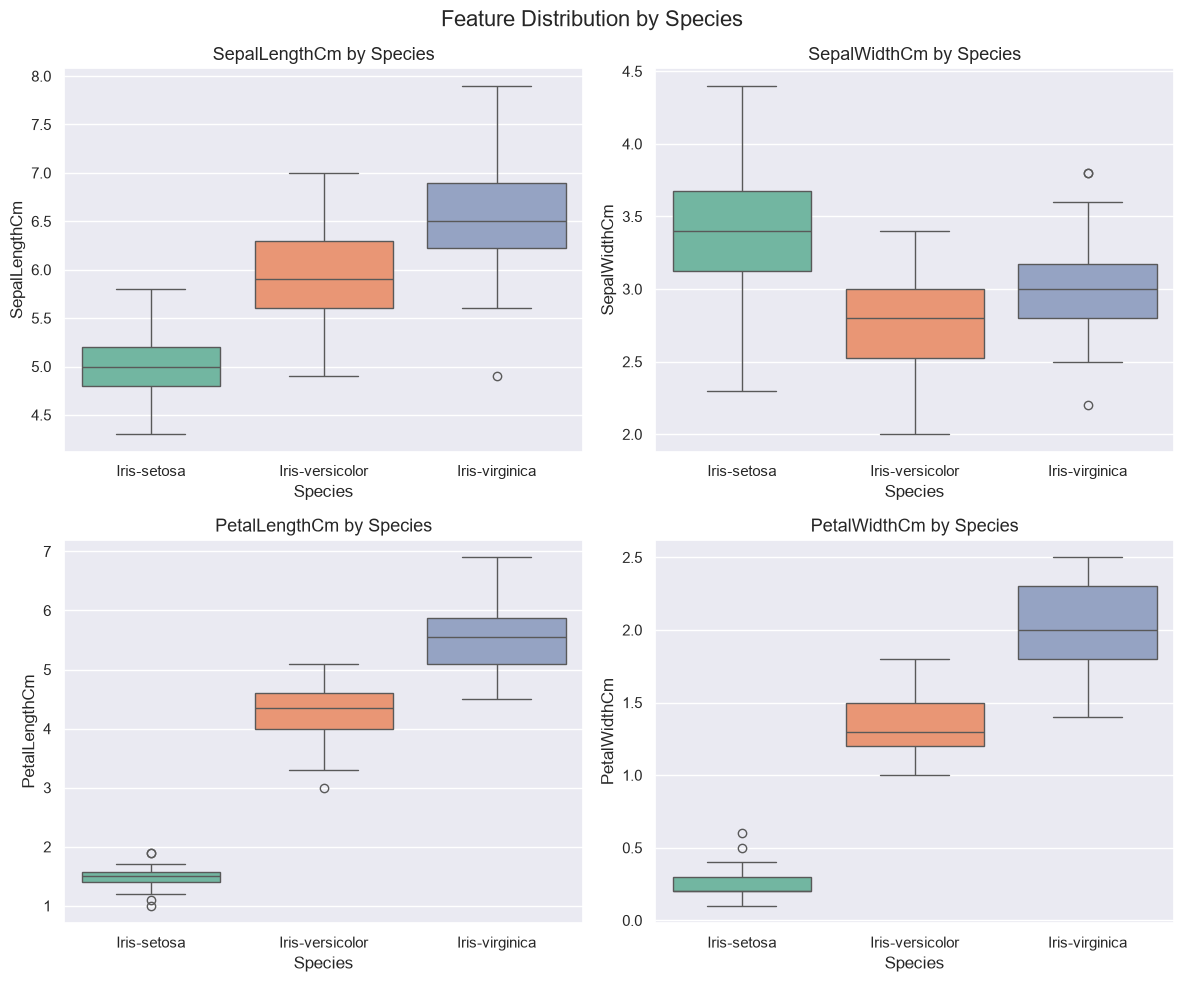

In [19]:
# boxplots of features by species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

for i, feature in enumerate(features):
    ax = axes[i//2, i%2]
    sns.boxplot(data=df, x='Species', y=feature, hue='Species', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{feature} by Species', fontsize=13)

plt.suptitle("Feature Distribution by Species", fontsize=16)
plt.tight_layout()
plt.show()

## 4. Model Building

In [20]:
# Preparing data for modeling
# Features and target
X = df.drop('Species', axis=1)
y = df['Species']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)
print("Encoded:", le.transform(le.classes_))

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded: [0 1 2]

Training samples: 120
Testing samples: 30


In [21]:
# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


## 5. Model Evaluation

In [22]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Model Accuracy: 100.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



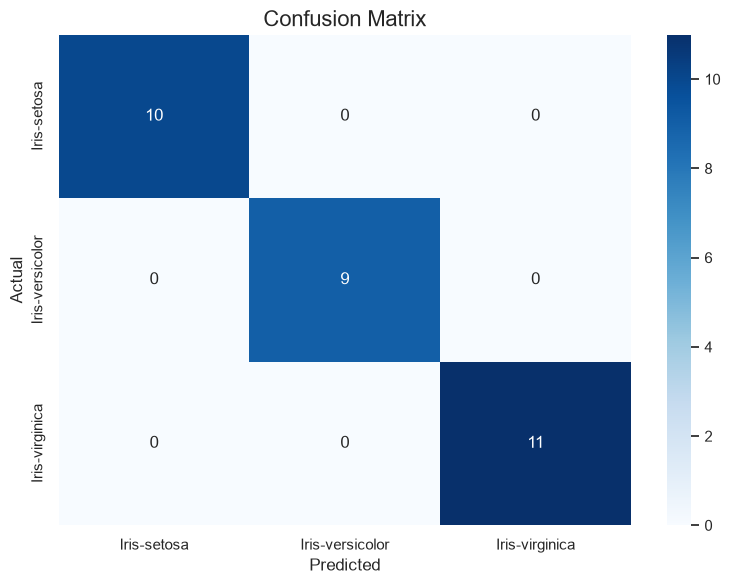

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

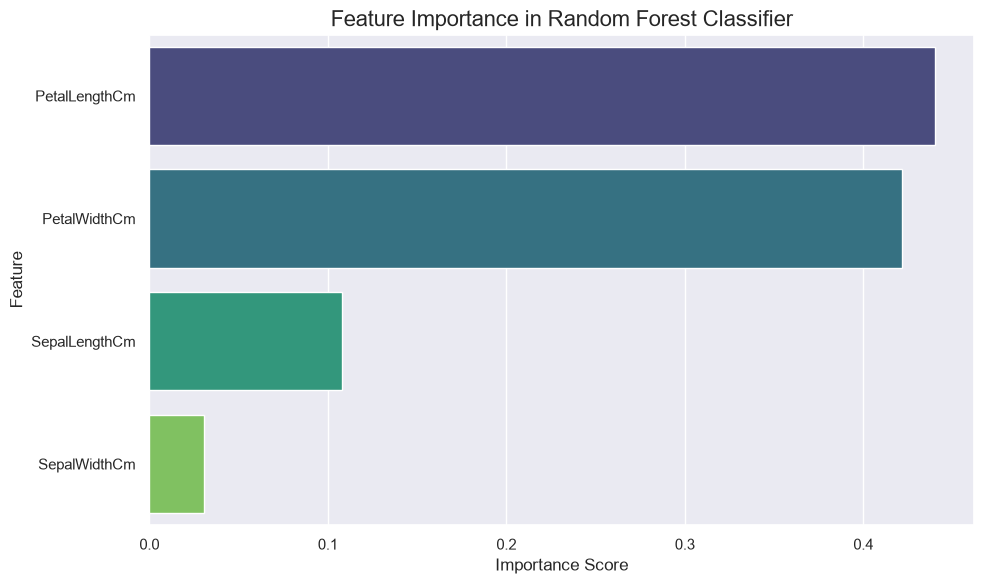

In [24]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title("Feature Importance in Random Forest Classifier", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 6. Key Insights & Conclusions

- The Random Forest Classifier achieved **100% accuracy** on the Iris dataset
- **Petal Length and Petal Width** are the most important features for classification
- **Iris-setosa** is the most clearly separable species — distinct from versicolor and virginica
- **Iris-versicolor and Iris-virginica** have some overlap making them slightly harder to distinguish
- The confusion matrix confirms the model classifies all three species with very high precision and recall
- Random Forest is an excellent choice for this classification task due to its robustness and high accuracy